In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import astropy
from astropy import units as u
import astropy.coordinates as coord
import glob
import os
import sys
%run VLSR_to_VLGSR.py

In [2]:
# defining a color scheme
# thank you to the colorblind-friendly color scheme checker! https://davidmathlogic.com/colorblind/#
c1 = "#000000"
c2 = "#F54E4E"
c3 = "#5656FB"
c4 = "#8ED47B"
c5 = "#947BD4"
c6 = "#F6B911"

def avg(reader, key, errorKey):
    sum = 0
    errorSum = 0
    points = 0
    for row in reader:
        # print(row)
        points += 1
        sum += float(row[key])
        errorSum += ((float(row[errorKey]))**2)
    if points == 0:
        return 0, 0
    else:
        sum = sum/points
        errorSum = np.sqrt(errorSum)/points
    return sum, errorSum

def weightedAvg(reader, key, errorKey, weight, errorWeight):
    numSum = 0
    denomSum = 0
    errorSum = 0
    for row in reader:
        numSum += float(row[key]) * float(row[weight])
        denomSum += float(row[weight])
    if numSum == 0:
        return 0,0
    else:
        weightedSum = numSum / denomSum
        for row in reader:
            errorSum +=(float(row[errorKey]) * float(row[weight]) / denomSum)**2
            errorSum += (float(row[errorWeight]) * ((denomSum * float(row[key])) - numSum) / denomSum)**2
        errorSum = np.sqrt(errorSum)
    return weightedSum, errorSum

def icrsToGal(long, lat):
    c_icrs = coord.SkyCoord(ra=long*u.degree, dec=lat*u.degree, frame='icrs')
    c_gal= c_icrs.galactic
    l = (c_gal.l.deg)
    b = (c_gal.b.deg)
    return l, b    

In [3]:
#to-do: improve this if time allows
#find average StdDev or range of noise over a certain range of regions
#for ease of copy-pasting CARTA output into a spreadsheet or CSV file

filepath = "results/gaussianFits/wholeRegions/noise/"
stddev = True
mean = False
noiseRange = False

#for RA: [19:37]
#for DEC: [39:58]
#otherwise, element of index 2 (or 4, for integral)
for filename in glob.glob(os.path.join(filepath, 'noise*')):
    with open(os.path.join(os.getcwd(), filename), 'r') as f:
        lines = f.readlines()
        output = ""
        if stddev:
            for i in lines:
                if "StdDev" in i:
                    output = output + i.split()[1] + "\t"
        elif noiseRange:
            maxvalue = -sys.maxsize
            minvalue = sys.maxsize
            for i in lines:
                if "Min" in i:
                    if float(i.split()[1]) < minvalue:
                        minvalue = float(i.split()[1])
                elif "Max" in i:
                    if float(i.split()[1]) > maxvalue:
                        maxvalue = float(i.split()[1])
            output = output + str(float(maxvalue - minvalue)) + ""
        else:
            # print(filename)
            blank = True
            for i in lines:
                if "integral" in i:
                    blank = False
                    output = output + str(float(i.split()[9])) + ""
            if blank:
                print("N/A")
        print(output)

8.763835433422e-3	6.361273306246e-3	5.566980173420e-3	7.103612827708e-3	7.823749552716e-3	
5.219548895424e-3	5.021791564982e-3	6.903815815018e-3	6.105524151291e-3	5.133779840553e-3	
5.384185004134e-3	4.845254321351e-3	5.254377693470e-3	2.463590173936e-3	4.702841687842e-3	
5.997652530781e-3	9.908532476933e-3	3.726793383218e-3	5.502677356343e-3	5.171209401782e-3	
4.873722518796e-3	4.461444826860e-3	4.751260047182e-3	7.166768819162e-3	3.047257704397e-3	
4.894206024339e-3	6.948933140238e-3	6.513441810700e-3	4.654369593356e-3	4.799903180091e-3	
4.483259741448e-3	3.514269034829e-3	4.651557546409e-3	4.817265194018e-3	3.752921587319e-3	
1.705000708710e-2	1.205263983774e-2	1.231597446407e-2	1.412131806654e-2	1.683298718542e-2	
5.975158542862e-3	5.615249133304e-3	5.384625155128e-3	6.832470392404e-3	5.750103369948e-3	
8.163265995376e-3	9.204747672888e-3	5.877414489578e-3	6.223158281204e-3	5.575888933499e-3	
6.267761704402e-3	5.116770812118e-3	5.894831445179e-3	4.557702601793e-3	8.668494060100e-3	

In [4]:
#read from text files

f1 = "HVCData/M31HVC+bridge_table.txt"
f2 = "HVCData/M31M33_deep_cloudlist.txt"
f3 = "HVCData/M33_HVC_table.txt"
f4 = "HVCData/asu.tsv"
useData = [f1, f3]
deHeij = [237, 304, 307, 391, 402]
cloudL = []
cloudB = []
cloudAngleM31 = []
cloudVlsr = []
cloudVlgsr = []
cloudName = []
cloudLists = [cloudL, cloudB, cloudAngleM31, cloudVlsr, cloudVlgsr]
galaxyL = []
galaxyB = []
galaxyAngleM31 = []
galaxyVlsr = []
galaxyVlgsr = []
galaxyName = []
galaxyLists = [galaxyL, galaxyB, galaxyAngleM31, galaxyVlsr, galaxyVlgsr]
msRa = []
msDec = []
msVlsr = []
msVlgsr = []
msAngleM31 = []

for file in useData:
    with open(file,"r") as f:
        lines = f.readlines()
    for i in range(2,len(lines)-1):
        # print(lines[i].split())
        if not ("Map" in lines[i] or "Deep" in lines[i] or "MS" in lines[i]):
            for j in range(len(cloudLists)):
                cloudLists[j].append(float(lines[i].split()[j]))
            cloudName.append(lines[i].split()[5])
        if "M31" in lines[i] or "M33" in lines[i]:
            for j in range(len(galaxyLists)):
                galaxyLists[j].append(float(lines[i].split()[j]))
            galaxyName.append(lines[i].split()[5][1:4])

with open(f4,"r") as f:
    lines = f.readlines()
    for i in lines:
        # print(i.split())
        try:
            if int(i.split()[0]) in deHeij:
                ra = float(i.split()[3])*15 + float(i.split()[4])/4
                dec1 = float(i.split()[5])
                dec2 = float(i.split()[6])/60
                if dec1 < 0:
                    dec2 = dec2 * -1
                dec = dec1 + dec2
                msRa.append(ra)
                msDec.append(dec)
                msVlsr.append(float(i.split()[7]))
                msVlgsr.append(float(i.split()[8]))
                l, b = icrsToGal(ra, dec)
                msAngleM31.append(angleFromM31(l, b))
        except (ValueError, IndexError):
            pass

In [5]:
#read from the whole cloud parameters
#derive (spatial) areas (there should be 3) -> area in cm^2
#derive uncertainty in area (just 1)
#derive (Gaussian) area (specify whether it should be whole cloud, average, or intensity-weighted average)
#derive NHI
#derive cloud mass
#derive VGLSR velocities
#derive angle from M31

# weighting = 1
#0 for whole-cloud fit properties, 1 for arithmetic average, 2 for intensity-weighted average
areaToUse = 0
#0 for Gaussian, 1 for approximation 1
#default to 0, being the most reliable approximation
path = "./results/cloudParameters/"

NHICONST = 1.82e+18 #1/cm^2
SOLARMASS = 2e+30 #kg
DIST = 800 #kpc
KPCTOCM = 3e+21 #centimeters
PIXTOARCMIN = 10.0/3.0 #arcmin, 1 degree = 60 arcmin
HMASS = 0.001008 #kg/mol
AVOGADRO = 6.022e+23

csvData = [["Name", "l (deg)", "b (deg)", "Area (approx.) (arcmin^2)", "Area (Gaussian) (arcmin^2)", "Area e (arcmin^2)", "Amp (K)", "Amp e (K)", "Center (VLSR) (km/s)", "Center (VLGSR) (km/s)", "Center e (km/s)", "FWHM (km/s)", "FWHM e (km/s)", "Integral (K*km/s)", "Integral e (K*km/s)", "NHI (atoms/cm^2)", "NHI e (atoms/cm^2)", "MHI (Msun)", "MHI e (Msun)", "M Dyn (Msun)", "M Dyn e (Msun)", "Angle (degrees)"]]
#so it's all 3 areas plus error
#all gaussian properties plus VGLSR
#NHI, MHI, and angle

filepath = path + "wholeCloudParameters/cloudParameters.csv"
outputpath = path + "wholeCloudParameters/derivedCloudParameters.csv"
regionName = []
regionAmp = []
regionVlsr = []
regionVlgsr = []
regionFWHM = []
regionAngleM31 = []
regionLats = []
regionLongs = []
regionL = []
regionB = []
regionNhi = []
regionMhi = []
regionMdyn = []
regionMratio = []
with open(filepath, encoding="utf-16") as csvfile:
    csvreader = csv.DictReader(csvfile, delimiter = ',')
    for row in csvreader:
        # print(row)
        # tempweighting = 0
        name = row["Name"]
        regionName.append(name)
        area1 = int(row["Area (approx.)"]) *  PIXTOARCMIN**2
        # area2 = int(row["Area 2 (approx.)"]) *  PIXTOARCMIN**2
        # scaleFactor = float(row["Scale (pix)"])
        boundingArea = float(row["Bounding area (px^2)"])
        major = float(row["Major (arcmin)"])
        minor = float(row["Minor (arcmin)"])
        majorE = float(row["Minor e (arcmin)"])
        minorE = float(row["Major e (arcmin)"])
        area3 = major * minor * np.pi * 0.25 #arcmin
        areaE = np.pi * 0.25 * np.sqrt((major**2)*(majorE) + (minor**2)*(minorE))
        scaleFactor = boundingArea / (area3/(PIXTOARCMIN**2))
        rad = np.sqrt(major * minor) * 60.0 / 1000.0 #kpc
        radE = np.sqrt((majorE**2 * 0.25 * (minor/major)) + (minorE**2 * 0.25 * (major/minor))) * 60.0 / 1000.0 
        long = float(row["Long"])
        regionLongs.append(long)
        lat = float(row["Lat"])
        regionLats.append(lat)
        l, b = icrsToGal(long, lat)
        regionL.append(l)
        regionB.append(b)
        # print(l,b)
        # print(name, long, lat, major, minor)
        try:
            centerVLSR = float(row["Center (km/s)"])
            centerVLGSR = velConversion(l,b,centerVLSR)[2]
        except ValueError:
            centerVLSR, centerVLGSR = np.NaN, np.NaN
        try:
            # print(name, scaleFactor)
            amp = float(row["Amp (K)"]) * scaleFactor
            ampE = float(row["Amp e (K)"]) * scaleFactor
            centerE = float(row["Center e (km/s)"])
            FWHM = float(row["FWHM (km/s)"])
            FWHME = float(row["FWHM e (km/s)"])
            integral = float(row["integral (K*km/s)"]) * scaleFactor
            integralE = float(row["integral e (K*km/s)"]) * scaleFactor
        except ValueError:
            amp, ampE, centerE, FWHM, FWHME, integral, integralE = np.NaN, np.NaN, np.NaN, np.NaN, np.NaN, np.NaN, np.NaN
            # tempWeighting = 1
        if False:
            nameFormat = name.replace(" ", "")
            nameFormat = nameFormat[0:1].lower() + nameFormat[1:]
            regionFilepath = path + nameFormat + ".csv"
            # print(regionFilepath)
            with open(regionFilepath) as regionCsvfile:
                regionCsvreader = csv.DictReader(regionCsvfile, delimiter=',')
                #function to take avgs and weightedavgs
                #and error propagation
                listOfDicts = []
                for row in regionCsvreader:
                    listOfDicts.append(dict(row))
                if weighting == 1:
                    amp, ampE = avg(listOfDicts,"amp (K)","amp e (K)")
                    centerVLSR, centerE = avg(listOfDicts,"center (km/s)","center e (km/s)")
                    FWHM, FWHME = avg(listOfDicts,"FWHM (km/s)","FWHM e (km/s)")
                    integral, integralE = avg(listOfDicts,"integral (K*km/s)","integral e (K*km/s)")
                    centerVLGSR = velConversion(l,b,centerVLSR)[2]
                else:
                    amp, ampE = weightedAvg(listOfDicts,"amp (K)","amp e (K)","amp (K)","amp e (K)")
                    centerVLSR, centerE = weightedAvg(listOfDicts,"center (km/s)","center e (km/s)","amp (K)","amp e (K)")
                    FWHM, FWHME = weightedAvg(listOfDicts,"FWHM (km/s)","FWHM e (km/s)","amp (K)","amp e (K)")
                    integral, integralE = weightedAvg(listOfDicts,"integral (K*km/s)","integral e (K*km/s)","amp (K)","amp e (K)")
                    centerVLGSR = velConversion(l,b,centerVLSR)[2]
        regionAmp.append(amp)
        regionFWHM.append(FWHM)
        nhi = NHICONST * integral
        nhiE = NHICONST * integralE
        regionNhi.append(nhi)
        if areaToUse == 0:
            area = area3
        else:
            area = area1
        # else:
        #     area = area2
        areaCM = area * (np.pi**2) * DIST**2 * KPCTOCM**2 / ((60*180)**2)
        natoms = nhi * areaCM
        natomsE = nhiE * areaCM
        mhi = natoms * HMASS / (AVOGADRO * SOLARMASS)
        mhiE = natomsE * HMASS / (AVOGADRO * SOLARMASS)
        regionMhi.append(mhi)
        mDyn = (2.5e+5) * rad * FWHM**2
        mDynE = (2.5e+5) * np.sqrt((radE*(FWHM**2))**2 + (rad*2*FWHM*FWHME)**2)
        regionMdyn.append(mDyn)
        regionMratio.append(mDyn / mhi)
        # print(long)
        # print(lat)
        angle = angleFromM31(l,b)
        csvData.append([name, l, b, area1, area3, areaE, amp, ampE, centerVLSR, centerVLGSR, centerE, FWHM, FWHME, integral, integralE, nhi, nhiE, mhi, mhiE, mDyn, mDynE, angle])
        if centerVLSR != 0:
            regionVlsr.append(centerVLSR)
            regionVlgsr.append(centerVLGSR)
        else:
            regionVlsr.append(np.NaN)
            regionVlgsr.append(np.NaN)
        regionAngleM31.append(angle)

        # print(centerVLSR, centerVLGSR, nhi, areaCM, natoms, mhi, angle, mDyn, mDynE)

with open(outputpath, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(csvData)

print(outputpath)

#read from CSV. we need all files from the cloudParameters

./results/cloudParameters/wholeCloudParameters/derivedCloudParameters.csv


In [ ]:
#can astropy do the unit conversions? the answer is probably, but I won't

if False:
    fk5 = coord.SkyCoord(
        ra = 21.2010 * u.deg,
        dec = 37.4126 * u.deg,
        radial_velocity = -297.7446 * u.km / u.s,
        frame = "fk5",
    )
    v_sun = coord.Galactocentric().galcen_v_sun.to_cartesian()
    gal = fk5.transform_to(coord.Galactic)
    print(gal)
    cart_data = gal.data.to_cartesian()
    unit_vector = cart_data / cart_data.norm()
    v_proj = v_sun.dot(unit_vector)
    print(fk5.radial_velocity + v_proj)

<SkyCoord (Galactic): (l, b) in deg
    (130.23546716, -24.98551343)
 (radial_velocity) in km / s
    (-297.7446,)>
-138.63968680081442 km / s


In [10]:
regionsM31 = ["A", "H", "J"]
regionsAmbiguous = ["B", "C", "D", "G", "I", "K"]
regionsNew = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O"]
rM31Longs = []
rM31Lats = []
rAmbLongs = []
rAmbLats = []
rNewAngleM31 = []
rNewVlsr = []
rNewVlgsr = []
for i in range(len(regionName)):
    if regionName[i][-1:] in regionsM31:
        rM31Longs.append(regionLongs[i])
        rM31Lats.append(regionLats[i])
    if regionName[i][-1:] in regionsAmbiguous:
        rAmbLongs.append(regionLongs[i])
        rAmbLats.append(regionLats[i])
    if regionName[i][-1:] in regionsNew:
        rNewAngleM31.append(regionAngleM31[i])
        rNewVlsr.append(regionVlsr[i])
        rNewVlgsr.append(regionVlgsr[i])
# print(rM31Lats)
# print(rM31Longs)

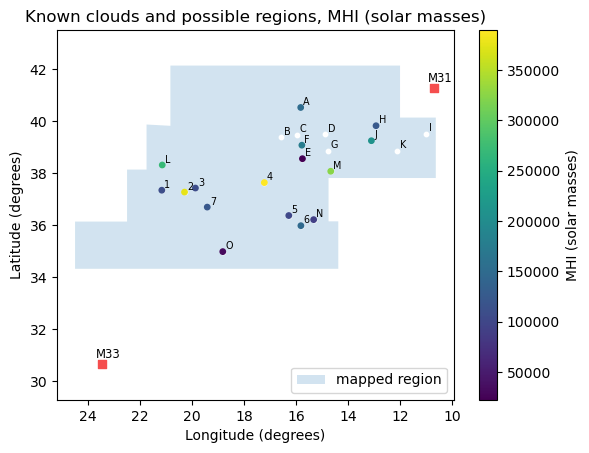

In [8]:
galaxyLong = []
galaxyLat = []

#to-do: improve

mapLongs = [20.833,12,12,10.625,10.625,14.75,14.75,14.375,14.375,24.5,24.5,22.5,22.5,21.75,21.75,20.833]
mapLats = [42.15,42.15,40.15,40.15,37.825,37.825,36.159,36.159,34.333,34.333,36.15,36.15,38.15,38.15,39.883,39.833]
cb = "MHI"
cbUnit = cb + " (solar masses)"
colorMap = regionMhi

for i in range(len(galaxyL)):
    gc = coord.SkyCoord(l=galaxyL[i]*u.degree, b=galaxyB[i]*u.degree, frame='galactic')
    gc_icrs = gc.transform_to("icrs")
    long = (gc_icrs.ra.deg)
    lat = (gc_icrs.dec.deg)
    galaxyLong.append(long)
    galaxyLat.append(lat)

# didn't end up needing these but they may come in handy
scaledRegionNhi = np.array(regionNhi) / 1e+18
scaledRegionMhi = np.array(regionMhi) / 1e+5

fig, ax = plt.subplots(1,1)
plt.axis("equal")
plt.fill(mapLongs, mapLats, alpha=0.2, label="mapped region")
if cb == "" or cb == "updated":
    ax.scatter(regionLongs,regionLats,marker="+",c=c1,s=15,label="HVCs between M31 and M33")
    ax.scatter(rM31Longs,rM31Lats,marker="o",c=c6,s=20,label="HVCs associated with M31")
    ax.scatter(rAmbLongs,rAmbLats,marker="D",c=c5,s=15,label="Ambiguous regions")
    cbTitle = ", " + cb
else:
    ax.scatter(regionLongs,regionLats,marker="o",c="white",s=10)
    sc = ax.scatter(regionLongs,regionLats,marker="o",c=colorMap,s=15,cmap="viridis")
    clb = plt.colorbar(sc,label=cbUnit)
    cbTitle = ", " + cbUnit

ax.scatter(galaxyLong,galaxyLat,marker="s",c=c2,s=30)
for i in range(len(galaxyName)):
    plt.annotate(galaxyName[i],(galaxyLong[i]+0.25,galaxyLat[i]+0.25),size="small")
for i in range(len(regionName)):
    # plt.annotate(round(regionFWHM[i],1),(regionLongs[i],regionLats[i]+0.1),size="x-small")
    plt.annotate(regionName[i][-1:],(regionLongs[i]-0.1,regionLats[i]+0.1),size="x-small")
ax.annotate(galaxyLong,galaxyLat)
ax.xaxis.set_inverted(True)

plt.xlabel("Longitude (degrees)")
plt.ylabel("Latitude (degrees)")
plt.title("Known clouds and possible regions" + cbTitle)
plt.legend(loc="lower right")

plt.savefig("./figures/cloudsRegions"+cb+".png",dpi=300 )

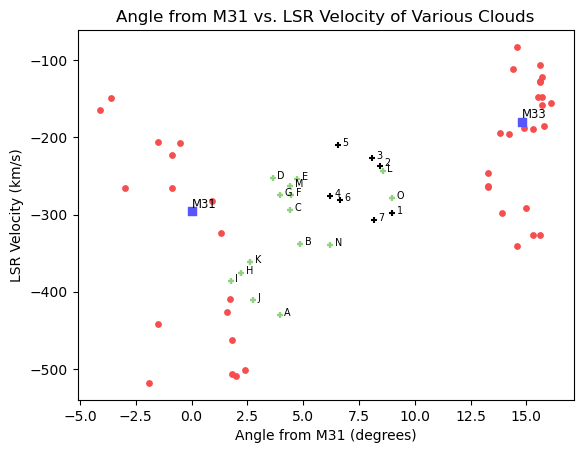

In [11]:
annotations = True
# depending on how many things we want to plot, annotating every point is going to get cluttered. a legend may be preferable
plotVlgsr = False

cloudV, regionV, galaxyV, msV = [], [], [], []
velType = ""
fileStr = ""
if plotVlgsr:
    cloudV = cloudVlgsr
    regionV = regionVlgsr
    galaxyV = galaxyVlgsr
    newV = rNewVlgsr
    msV = msVlgsr
    velType = "LGSR"
else:
    cloudV = cloudVlsr
    regionV = regionVlsr
    galaxyV = galaxyVlsr
    newV = rNewVlsr
    msV = msVlsr
    velType = "LSR"

f = plt.figure()
# f.set_size_inches(10,5)

sample = [0,5,15]
sample2 = [100,-100,-200]
v1 = 4.7
v2 = 10.2
min = -75
max = 5
vx1 = np.linspace(v1,v1,50)
vy1 = np.linspace(min,max,50)
vx2 = np.linspace(v2,v2,50)
vy2 = np.linspace(min,max,50)
plt.scatter(cloudAngleM31,cloudV,c=c2,marker="o",s=15,label="HVCs around M31 and M33")
plt.scatter(regionAngleM31,regionV,c=c1,marker="+",s=15,label="HI cloud bridge")
plt.scatter(galaxyAngleM31,galaxyV,c=c3,marker="s",s=30,label="Galaxies")
plt.scatter(rNewAngleM31,newV,c=c4,marker="+",s=20)
if annotations:
    for i in range(len(regionName)):
        plt.annotate(regionName[i][-1:],(regionAngleM31[i]+0.2,regionV[i]-1),size="x-small")
    for i in range(len(galaxyName)):
        plt.annotate(galaxyName[i],(galaxyAngleM31[i],galaxyV[i]+5),size="small")
else:
    plt.scatter(msAngleM31,msV,c=c6,marker="p",s=15,label="Magellanic Stream clouds")
    plt.legend()
    fileStr = "WithMS"
# plt.plot(vx1,vy1,c="k")
# plt.plot(vx2,vy2,c="k")

plt.xlabel("Angle from M31 (degrees)")
plt.ylabel(velType + " Velocity (km/s)")
plt.title("Angle from M31 vs. " + velType + " Velocity of Various Clouds")

plt.savefig("./figures/angleM31V"+velType+fileStr+".png",dpi=300)

# =H2-$AD$4*(SIN(RADIANS(E2))*SIN(RADIANS($AB$4))+COS(RADIANS(E2))*COS(RADIANS($AB$4))*COS(RADIANS(C2)-RADIANS($Z$4)))+$AD$3*(SIN(RADIANS(E2))*SIN(RADIANS($AB$3))+COS(RADIANS(E2))*COS(RADIANS($AB$3))*COS(RADIANS(C2)-RADIANS($Z$3)))

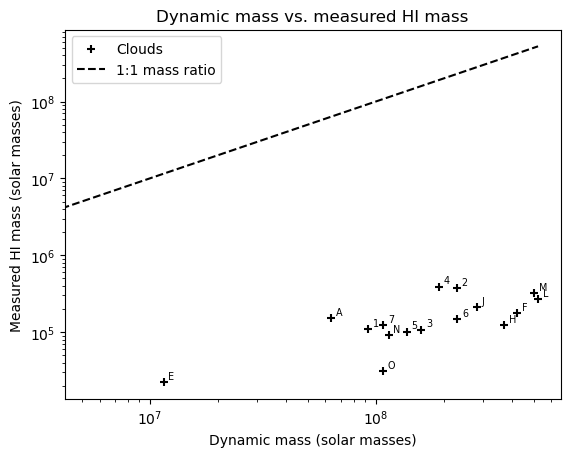

In [72]:
maxMdyn = np.nanmax(regionMdyn)
linear = np.linspace(0,maxMdyn,100)
plt.scatter(regionMdyn, regionMhi, marker="+", c=c1, label="Clouds")
for i in range(len(regionName)):
    plt.annotate(regionName[i][-1:],(regionMdyn[i]*1.05,regionMhi[i]*1.1),size="x-small")
plt.loglog(linear,linear,"k--",label="1:1 mass ratio")

plt.xlabel("Dynamic mass (solar masses)")
plt.ylabel("Measured HI mass (solar masses)")
plt.legend()
plt.title("Dynamic mass vs. measured HI mass")
plt.savefig("./figures/Mratio.png",dpi=300)
